In [1]:
# general python modules for scientific analysis
import sys, pathlib, os, itertools
import numpy as np
import pandas as pd
import matplotlib.pylab as plt

# add the physion path:
sys.path.append('../../../physion/src')
from physion.analysis.read_NWB import Data, scan_folder_for_NWBfiles
from physion.analysis.process_NWB import EpisodeData
from physion.dataviz.raw import plot as plot_raw
from physion.dataviz.episodes.trial_average import plot as plot_trial_average
#from physion.dataviz.episodes.trial_average import plot_test
from physion.utils import plot_tools as pt

from physion.analysis import tools

In [2]:
def compute_high_arousal_cond(behav_episodes,
                              pupil_threshold=None,
                              running_speed_threshold=None, 
                              metric = None):
    if metric=='pupil':
        if pupil_threshold==None:
            print("Error, no pupil threshold given")
        HAcond = (behav_episodes.pupil_diameter.mean(axis=1)>pupil_threshold)

    elif metric=='locomotion':
        if running_speed_threshold==None:
            print("Error, no running speed threshold given")
        HAcond = (behav_episodes.running_speed.mean(axis=1)>running_speed_threshold) #### a discuter 50% of points or something
        
        
    else:
        print("Error, no metric given to compute arousal condition")

    return HAcond

In [3]:
def plot_behavior_in_episodes(data,
                              ax=None,
                              running_speed_threshold=0.1,
                              pupil_threshold=2.9, 
                              metric=None):
    
    protocols = [p for p in data.protocols if (p!='grey-10min')] # remove visual-stimulus-free protocol

    if ax is None:
        fig, ax = plt.subplots(1, figsize=(2,1.3))
        plt.subplots_adjust(wspace=0.3, hspace=0.3)
    else:
        fig = None

    HAcount, LAcount = [], []
    for p, protocol in enumerate(protocols):

        behav_episodes = EpisodeData(data, 
                             quantities=['Pupil', 'Running-Speed'],
                             protocol_name=protocol,
                             prestim_duration=0,
                             verbose=False)
        
        # HAcond: high arousal condition
        HAcond = compute_high_arousal_cond(behav_episodes, pupil_threshold, running_speed_threshold, metric=metric)
            
        ax.plot(behav_episodes.pupil_diameter.mean(axis=1)[~HAcond],
                behav_episodes.running_speed.mean(axis=1)[~HAcond], 'o', color='grey')
        ax.plot(behav_episodes.pupil_diameter.mean(axis=1)[HAcond],
                behav_episodes.running_speed.mean(axis=1)[HAcond], 'o', color='orangered')
        
        HAcount.append(np.sum(HAcond))
        LAcount.append(np.sum(~HAcond))
        
    ax.set_ylabel('run. speed (cm/s)')
    ax.set_xlabel('pupil size (mm)')
    ax.annotate('\n n=%i ep.' % np.sum(HAcount), (0, 1), color='orangered', xycoords='axes fraction', va='top')
    ax.annotate(' n=%i ep.' % np.sum(LAcount), (0, 1), color='grey', xycoords='axes fraction', va='top')
    
    return fig, ax

In [4]:
def plot_average_visually_evoked_activity(data,
                                          roiIndex=None,
                                          pupil_threshold=2.9,
                                          running_speed_threshold=0.1, 
                                          metric=None, 
                                          dataset = "NDNF"):

    protocol = data.protocols
    RESULTS = {'significant':[], 'response':[], 'session':[]}

    fig, AX = plt.subplots(1, 1, figsize=(2, 1.3), squeeze=False)
    pt.plt.subplots_adjust(wspace=0.3, hspace=0.3)
    AX[0][0].annotate(protocol[0].replace('ff-gratings-8orientation-2contrasts-15repeats', '8ori-2contrasts'),
                     (0.5,1.4),
                      xycoords='axes fraction', 
                      ha='center')

    behav_episodes = EpisodeData(data, 
                                 quantities=['Pupil', 'Running-Speed'],
                                 protocol_name=protocol,
                                 prestim_duration=0,
                                 verbose=False)
        
    HMcond = compute_high_arousal_cond(behav_episodes, pupil_threshold, running_speed_threshold, metric="locomotion")
   
    episodes = EpisodeData(data,
                           quantities=['dFoF'],
                           protocol_name=protocol,
                           verbose=False)



    if dataset=="NDNF":
        protocols = [p for p in data.protocols if (p!='grey-10min')] # remove visual-stimulus-free protocol

        # prepare array for final results (averaged over sessions)
        RESULTS = {}
        for protocol in protocols:
            RESULTS[protocol] = {'significant':[], 'response':[], 'session':[]}


        fig, AX = plt.subplots(5, len(protocols),
                                  figsize=(7,5))
        pt.plt.subplots_adjust(wspace=0.3, hspace=0.3)
    
        for p, protocol in enumerate(protocols):
    
            behav_episodes = EpisodeData(data, 
                                 quantities=['Pupil', 'Running-Speed'],
                                 protocol_name=protocol,
                                 prestim_duration=0,
                                 verbose=False)
            
            # HMcond: high movement condition
            HMcond = compute_high_arousal_cond(behav_episodes, pupil_threshold, running_speed_threshold, metric=metric)
            
            episodes = EpisodeData(data,
                                   quantities=['dFoF'],
                                   protocol_name=protocol,
                                   verbose=False)
            varied_keys = [k for k in episodes.varied_parameters.keys() if k!='repeat']
            varied_values = [episodes.varied_parameters[k] for k in varied_keys]
    
            AX[0][p].annotate(protocol.replace('Natural-Images-4-repeats','natural-images'),
                              (0.5,1.4),
                              xycoords='axes fraction', ha='center')
    
            i=0
            for values in itertools.product(*varied_values):
    
                stim_cond = episodes.find_episode_cond(key=varied_keys, value=values)
                
                #inset
                inset = pt.inset(AX[i][p], [0.55, 0.9, 0.3, 0.2])
                rest = sum(stim_cond & (~HMcond))
                run  = sum(stim_cond & HMcond)
                inset.pie([rest, run], 
                           autopct='%1.1f%%', 
                           colors = ['grey', 'orangered'], 
                           textprops={'fontsize': 5}, 
                           #labeldistance=0.5)  # Move labels outside
                           pctdistance=2  )  # Move percentage text closer to the edge
    
                #rest trace
                if np.sum(~HMcond & stim_cond)>1:
                    plot_trial_average(episodes, 
                                       roiIndex=roiIndex,
                                       condition=stim_cond & (~HMcond),
                                       with_std=False, with_stim=False,
                                       color='grey',
                                       AX=[[AX[i][p]]], no_set=True)
                #running trace
                if np.sum(HMcond & stim_cond)>1:
                    plot_trial_average(episodes, 
                                       roiIndex=roiIndex,
                                       condition=stim_cond & HMcond,
                                       with_std=False, with_stim=True,
                                       color='orangered',
                                       AX=[[AX[i][p]]], no_set=True)
    
                RESULTS[protocol]['significant'].append([])
                RESULTS[protocol]['response'].append([])
                RESULTS[protocol]['session'].append([])
                i+=1
    
        if roiIndex is None:
            AX[-1][0].annotate('single session ,   rec: %s \n --> mean$\pm$s.d. over n=%i ROIs' % (\
                                                            data.filename.replace('.nwb',''),data.nROIs),
                               (0, 0),
                              xycoords='axes fraction')
        else:
            AX[-1][0].annotate('roi #%i ,   rec: %s' % (1+roiIndex, data.filename.replace('.nwb','')),
                               (0, 0), xycoords='axes fraction')
    
        pt.set_common_ylims(AX)
        for ax in pt.flatten(AX):
            ax.axis('off')
            if np.isfinite(ax.dataLim.x0) and ax==AX[0][0]:
                pt.draw_bar_scales(ax,
                                   Xbar=1., Xbar_label='1s',
                                   Ybar=1, Ybar_label='1$\Delta$F/F', fontsize=7)
        pt.set_common_xlims(AX)


    #####################################################################
    protocol = data.protocols
    RESULTS = {'significant':[], 'response':[], 'session':[]}

    fig, AX = plt.subplots(1, 1, figsize=(2, 1.3), squeeze=False)
    pt.plt.subplots_adjust(wspace=0.3, hspace=0.3)
    AX[0][0].annotate(protocol[0].replace('ff-gratings-8orientation-2contrasts-15repeats', '8ori-2contrasts'),
                     (0.5,1.4),
                      xycoords='axes fraction', 
                      ha='center')

    behav_episodes = EpisodeData(data, 
                                 quantities=['Pupil', 'Running-Speed'],
                                 protocol_name=protocol,
                                 prestim_duration=0,
                                 verbose=False)
        
    HMcond = compute_high_arousal_cond(behav_episodes, pupil_threshold, running_speed_threshold, metric="locomotion")
   
    episodes = EpisodeData(data,
                           quantities=['dFoF'],
                           protocol_name=protocol,
                           verbose=False)
    
    #rest trace
    plot_trial_average(episodes, 
                       roiIndex=roiIndex,
                       condition=(~HMcond),
                       with_std=False, with_stim=False,
                       color='grey',
                       AX=[[AX[0][0]]], 
                       no_set=True)
       
    #running trace
    plot_trial_average(episodes, 
                    roiIndex=roiIndex,
                    condition=(HMcond),
                    with_std=False, with_stim=True,
                    color='orangered',
                    AX=[[AX[0][0]]], 
                    no_set=True)
    
    #inset
    inset = pt.inset(AX[0][0], [0.55, 0.9, 0.3, 0.2])
    rest = sum(~HMcond)
    run  = sum(HMcond)
    inset.pie([rest, run], 
               autopct='%1.1f%%', 
               colors = ['grey', 'orangered'], 
               textprops={'fontsize': 5}, 
               pctdistance=2  )  # Move percentage text closer to the edge
    
    RESULTS['significant'].append([])
    RESULTS['response'].append([])
    RESULTS['session'].append([])
        

    if roiIndex is None:
        AX[0][0].annotate('single session ,   rec: %s \n --> mean$\pm$s.d. over n=%i ROIs' % (\
                                                        data.filename.replace('.nwb',''),data.nROIs),
                           (0, 0),
                          xycoords='axes fraction')
    else:
        AX[0][0].annotate('roi #%i ,   rec: %s' % (1+roiIndex, data.filename.replace('.nwb','')),
                           (0, 1.2), xycoords='axes fraction')


    ##########################################
    
    return fig

<>:107: SyntaxWarning: invalid escape sequence '\p'
<>:121: SyntaxWarning: invalid escape sequence '\D'
<>:183: SyntaxWarning: invalid escape sequence '\p'
<>:107: SyntaxWarning: invalid escape sequence '\p'
<>:121: SyntaxWarning: invalid escape sequence '\D'
<>:183: SyntaxWarning: invalid escape sequence '\p'
C:\Users\laura.gonzalez\AppData\Local\Temp\ipykernel_42852\2111973600.py:107: SyntaxWarning: invalid escape sequence '\p'
  AX[-1][0].annotate('single session ,   rec: %s \n --> mean$\pm$s.d. over n=%i ROIs' % (\
C:\Users\laura.gonzalez\AppData\Local\Temp\ipykernel_42852\2111973600.py:121: SyntaxWarning: invalid escape sequence '\D'
  Ybar=1, Ybar_label='1$\Delta$F/F', fontsize=7)
C:\Users\laura.gonzalez\AppData\Local\Temp\ipykernel_42852\2111973600.py:183: SyntaxWarning: invalid escape sequence '\p'
  AX[0][0].annotate('single session ,   rec: %s \n --> mean$\pm$s.d. over n=%i ROIs' % (\


In [5]:
def plot_average_visually_evoked_activity2(data,
                                           roiIndex=None,
                                           pupil_threshold=2.9,
                                           running_speed_threshold=0.1, 
                                           metric=None):
    
    protocols = [p for p in data.protocols if (p!='grey-10min')] # remove visual-stimulus-free protocol

    # prepare array for final results (averaged over sessions)
    RESULTS = {}
    for protocol in protocols:
        RESULTS[protocol] = {'significant':[], 'response':[], 'session':[]}


    fig, AX = plt.subplots(5, len(protocols),
                              figsize=(7,5))
    pt.plt.subplots_adjust(wspace=0.3, hspace=0.3)

    for p, protocol in enumerate(protocols):

        behav_episodes = EpisodeData(data, 
                             quantities=['Pupil', 'Running-Speed'],
                             protocol_name=protocol,
                             prestim_duration=0,
                             verbose=False)
        
        # HMcond: high movement condition
        HMcond = compute_high_arousal_cond(behav_episodes, pupil_threshold, running_speed_threshold, metric=metric)
        
        episodes = EpisodeData(data,
                               quantities=['dFoF'],
                               protocol_name=protocol,
                               verbose=False)
        varied_keys = [k for k in episodes.varied_parameters.keys() if k!='repeat']
        varied_values = [episodes.varied_parameters[k] for k in varied_keys]

        AX[0][p].annotate(protocol.replace('Natural-Images-4-repeats','natural-images'),
                          (0.5,1.4),
                          xycoords='axes fraction', ha='center')

        i=0
        for values in itertools.product(*varied_values):

            stim_cond = episodes.find_episode_cond(key=varied_keys, value=values)

            #inset
            inset = pt.inset(AX[i][p], [0.55, 0.9, 0.3, 0.2])
            rest = sum(stim_cond & (~HMcond))
            run  = sum(stim_cond & HMcond)
            inset.pie([rest, run], 
                       autopct='%1.1f%%', 
                       colors = ['grey', 'orangered'], 
                       textprops={'fontsize': 5}, 
                       #labeldistance=0.5)  # Move labels outside
                       pctdistance=2  )  # Move percentage text closer to the edge

            #rest trace
            if np.sum(~HMcond & stim_cond)>1:
                plot_trial_average(episodes, 
                                   roiIndex=roiIndex,
                                   condition=stim_cond & (~HMcond),
                                   with_std=False, with_stim=False,
                                   color='grey',
                                   AX=[[AX[i][p]]], no_set=True)
            #running trace
            if np.sum(HMcond & stim_cond)>1:
                plot_trial_average(episodes, 
                                   roiIndex=roiIndex,
                                   condition=stim_cond & HMcond,
                                   with_std=False, with_stim=True,
                                   color='orangered',
                                   AX=[[AX[i][p]]], no_set=True)

            RESULTS[protocol]['significant'].append([])
            RESULTS[protocol]['response'].append([])
            RESULTS[protocol]['session'].append([])
            i+=1

    if roiIndex is None:
        AX[-1][0].annotate('single session ,   rec: %s \n --> mean$\pm$s.d. over n=%i ROIs' % (\
                                                        data.filename.replace('.nwb',''),data.nROIs),
                           (0, 0),
                          xycoords='axes fraction')
    else:
        AX[-1][0].annotate('roi #%i ,   rec: %s' % (1+roiIndex, data.filename.replace('.nwb','')),
                           (0, 0), xycoords='axes fraction')

    pt.set_common_ylims(AX)
    for ax in pt.flatten(AX):
        ax.axis('off')
        if np.isfinite(ax.dataLim.x0) and ax==AX[0][0]:
            pt.draw_bar_scales(ax,
                               Xbar=1., Xbar_label='1s',
                               Ybar=1, Ybar_label='1$\Delta$F/F', fontsize=7)
    pt.set_common_xlims(AX)
    
    return fig

<>:80: SyntaxWarning: invalid escape sequence '\p'
<>:94: SyntaxWarning: invalid escape sequence '\D'
<>:80: SyntaxWarning: invalid escape sequence '\p'
<>:94: SyntaxWarning: invalid escape sequence '\D'
C:\Users\laura.gonzalez\AppData\Local\Temp\ipykernel_42852\3221003352.py:80: SyntaxWarning: invalid escape sequence '\p'
  AX[-1][0].annotate('single session ,   rec: %s \n --> mean$\pm$s.d. over n=%i ROIs' % (\
C:\Users\laura.gonzalez\AppData\Local\Temp\ipykernel_42852\3221003352.py:94: SyntaxWarning: invalid escape sequence '\D'
  Ybar=1, Ybar_label='1$\Delta$F/F', fontsize=7)


In [99]:
def plot_average_visually_evoked_activity3(data,
                                           roiIndex=None,
                                           pupil_threshold=2.9,
                                           running_speed_threshold=0.1,
                                           metric=None):
    
    protocol = data.protocols
    RESULTS = {'significant':[], 'response':[], 'session':[]}

    fig, AX = plt.subplots(2, 1, figsize=(4, 2), squeeze=False)
    pt.plt.subplots_adjust(wspace=0.3, hspace=0.3)
    AX[0][0].annotate(protocol[0].replace('ff-gratings-8orientation-2contrasts-15repeats', '8ori-2contrasts'),
                     (0.5,1.4),
                      xycoords='axes fraction', 
                      ha='center')
    '''
    behav_episodes = EpisodeData(data, 
                                 quantities=['Pupil', 'Running-Speed'],
                                 protocol_name=protocol,
                                 prestim_duration=0,
                                 verbose=False)
    '''   
    
   
    episodes = EpisodeData(data,
                           quantities=['dFoF', 'Pupil', 'Running-Speed'],
                           protocol_name=protocol,
                           prestim_duration=0,
                           verbose=False)
    
    HMcond = compute_high_arousal_cond(episodes, pupil_threshold, running_speed_threshold, metric="locomotion")
    #HMcond = compute_high_arousal_cond(behav_episodes, pupil_threshold, running_speed_threshold, metric="locomotion")

    print(episodes.data.dFoF.shape)
    init_val = episodes.data.dFoF.mean(axis=0)[10631]
    max_val = np.max(episodes.data.dFoF.mean(axis=0))
    vdFoF = max_val - init_val
    print(vdFoF)
    
    #rest trace
    plot_trial_average(episodes, 
                       roiIndex=roiIndex,
                       condition=(~HMcond),
                       with_std=False, with_stim=False,
                       color='grey',
                       AX=[[AX[0][0]]], 
                       no_set=True)
       
    #running trace
    plot_trial_average(episodes, 
                       roiIndex=roiIndex,
                       condition=(HMcond),
                       with_std=False, with_stim=True,
                       color='orangered',
                       AX=[[AX[0][0]]], 
                       no_set=True)

    AX[0][0].set_xlabel("Time (0.5 ms)? check")
    AX[0][0].set_ylabel("dFoF ")
    
    #inset
    inset = pt.inset(AX[0][0], [0.55, 0.9, 0.3, 0.2])
    rest = sum(~HMcond)
    run  = sum(HMcond)
    inset.pie([rest, run], 
               autopct='%1.1f%%', 
               colors = ['grey', 'orangered'], 
               textprops={'fontsize': 5}, 
               pctdistance=2  )  # Move percentage text closer to the edge
    
    RESULTS['significant'].append([])
    RESULTS['response'].append([])
    RESULTS['session'].append([])
        

    if roiIndex is None:
        AX[0][0].annotate('single session ,   rec: %s \n --> mean$\pm$s.d. over n=%i ROIs' % (\
                                                        data.filename.replace('.nwb',''),data.nROIs),
                           (0, 0),
                          xycoords='axes fraction')
    else:
        AX[0][0].annotate('roi #%i ,   rec: %s' % (1+roiIndex, data.filename.replace('.nwb','')),
                           (0, 1.2), xycoords='axes fraction')


    #plot traces running speed
    
    AX[1][0].plot(np.arange(0,len(episodes.running_speed[0]),1), episodes.running_speed[~HMcond][roiIndex], color= 'grey')
    AX[1][0].plot(np.arange(0,len(episodes.running_speed[0]),1), episodes.running_speed[HMcond][roiIndex], color= 'orangered')
    AX[1][0].set_xlabel("Time (0.5 ms)? check")
    AX[1][0].set_ylabel("Speed (cm/s)")

    
    return fig

<>:77: SyntaxWarning: invalid escape sequence '\p'
<>:77: SyntaxWarning: invalid escape sequence '\p'
C:\Users\laura.gonzalez\AppData\Local\Temp\ipykernel_42852\1220729948.py:77: SyntaxWarning: invalid escape sequence '\p'
  AX[0][0].annotate('single session ,   rec: %s \n --> mean$\pm$s.d. over n=%i ROIs' % (\


# NDNF 2022

In [6]:
datafolder = os.path.join(os.path.expanduser('~'), 'DATA', 'In_Vivo_experiments','NDNF-WT-Dec-2022','NWBs')
SESSIONS = scan_folder_for_NWBfiles(datafolder)
SESSIONS['nwbfiles'] = [os.path.basename(f) for f in SESSIONS['files']]
#SESSIONS[['nwbfiles', 'subjects', 'dates', 'protocols']]

inspecting the folder "C:\Users\laura.gonzalez\DATA\In_Vivo_experiments\NDNF-WT-Dec-2022\NWBs" [...]
 -> found n=14 datafiles (in 27.2s) 


In [7]:
index = 2
filename = SESSIONS['files'][index]
data = Data(filename,
            verbose=False)
data.build_dFoF(verbose=False)

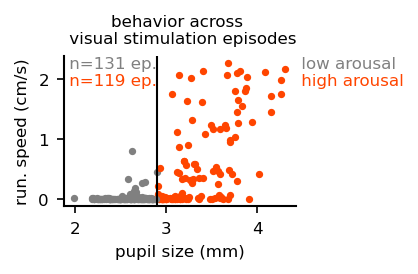

In [8]:
pupil_threshold = 2.9
fig, ax = plot_behavior_in_episodes(data, pupil_threshold=pupil_threshold, metric="pupil")
ax.set_title('behavior across \n visual stimulation episodes')
ax.annotate('\n high arousal', (1, 1), color='orangered', xycoords='axes fraction', va='top')
ax.annotate(' low arousal', (1, 1), color='grey', xycoords='axes fraction', va='top')
ax.axvline(x = pupil_threshold, color = 'black', label = 'threshold')

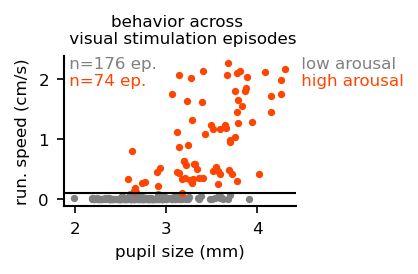

In [9]:
running_speed_threshold=0.1
pupil_threshold = 2.9
fig, ax = plot_behavior_in_episodes(data, running_speed_threshold=running_speed_threshold, metric="locomotion")
ax.set_title('behavior across \n visual stimulation episodes')
ax.annotate('\n high arousal', (1, 1), color='orangered', xycoords='axes fraction', va='top')
ax.annotate(' low arousal', (1, 1), color='grey', xycoords='axes fraction', va='top')
ax.axhline(running_speed_threshold, color = 'black', label = 'threshold')

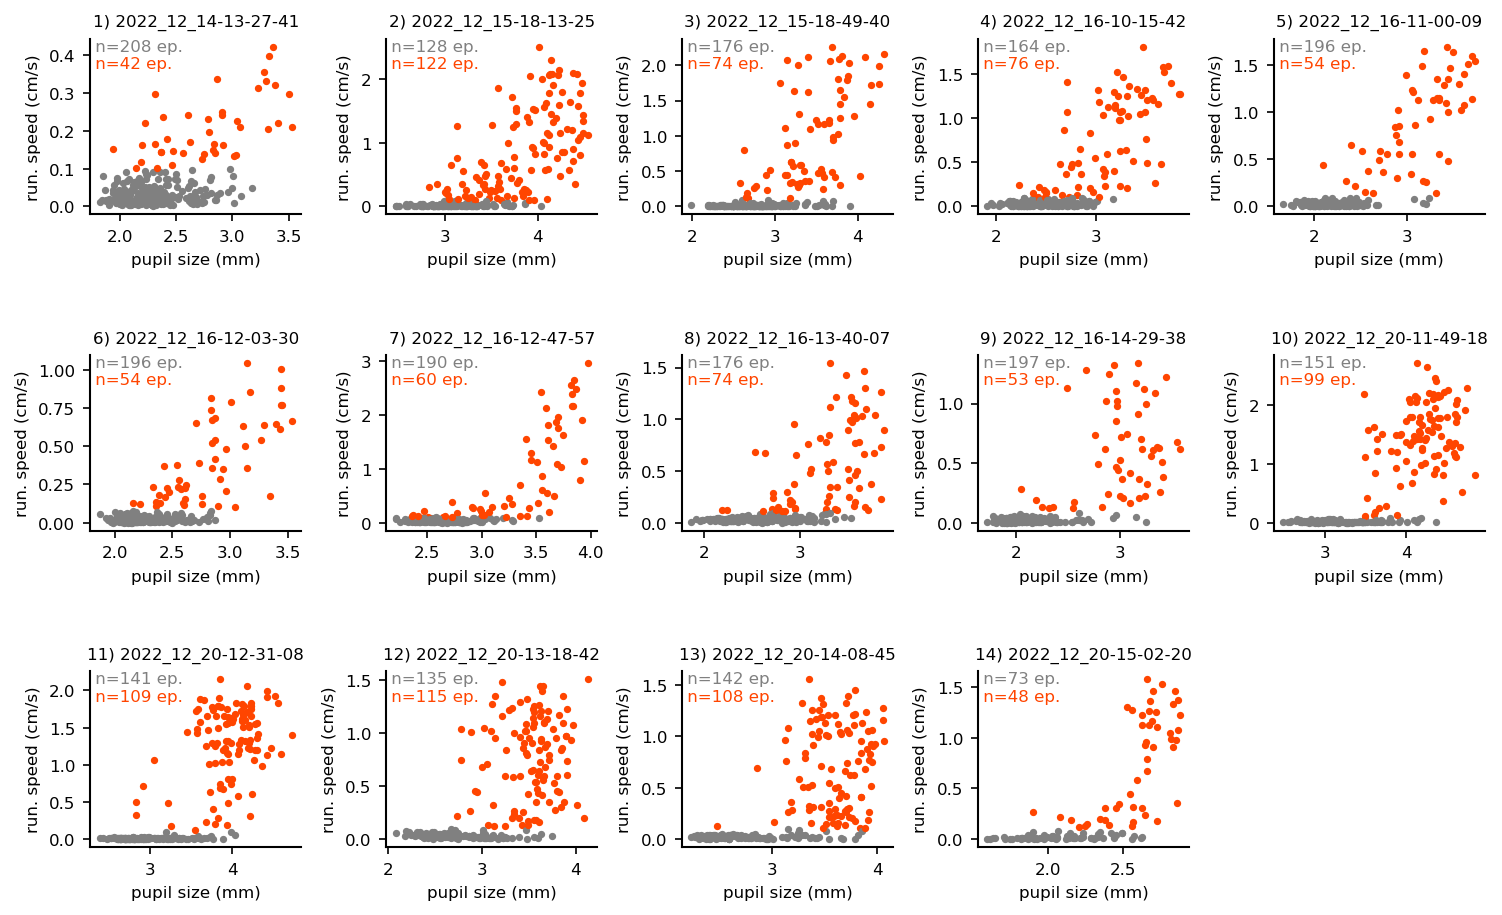

In [10]:
rows = 3
cols = 5
fig, AX = pt.plt.subplots(rows, cols, figsize=(12,7))
pt.plt.subplots_adjust(wspace=0.4, hspace=0.8)

for f, filename in enumerate(SESSIONS['files']):
    data = Data(filename, verbose=False)
    plot_behavior_in_episodes(data, ax=AX[int(f/5)][f%5], metric='locomotion')
    AX[int(f/5)][f%5].set_title(str(f+1)+') '+data.filename.replace('.nwb',''), fontsize=8)
    

for i in range(rows*cols-len(SESSIONS['files'])):
    AX[-1][i*(-1) - 1].axis('off')

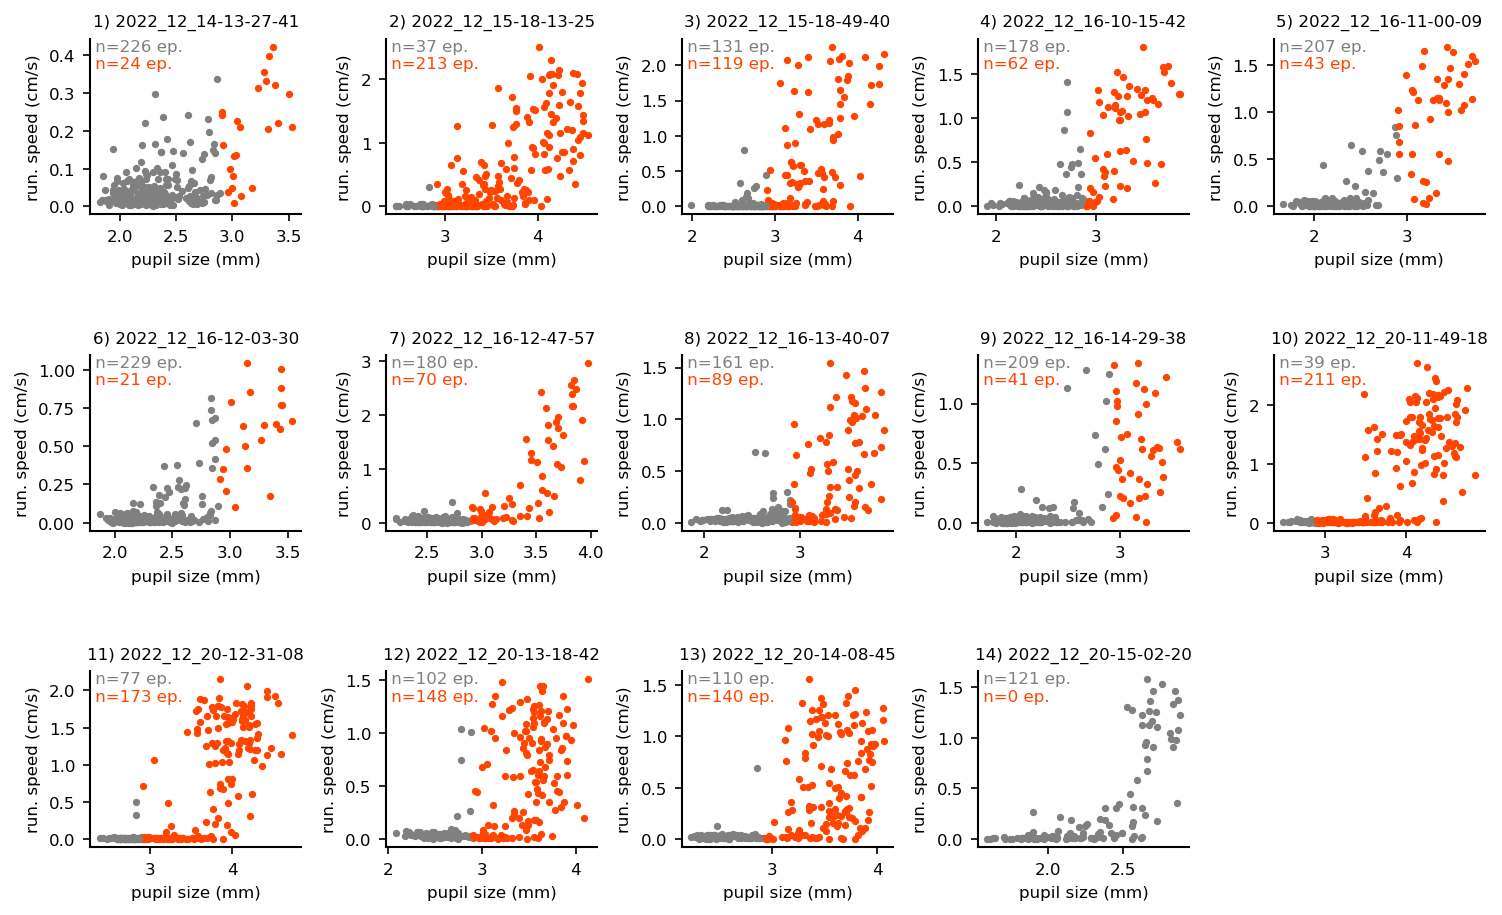

In [11]:
rows = 3
cols = 5
fig, AX = pt.plt.subplots(rows, cols, figsize=(12,7))
pt.plt.subplots_adjust(wspace=0.4, hspace=0.8)

for f, filename in enumerate(SESSIONS['files']):
    data = Data(filename, verbose=False)
    plot_behavior_in_episodes(data, ax=AX[int(f/5)][f%5], metric='pupil')
    AX[int(f/5)][f%5].set_title(str(f+1)+') '+data.filename.replace('.nwb',''), fontsize=8)
    

for i in range(rows*cols-len(SESSIONS['files'])):
    AX[-1][i*(-1) - 1].axis('off')

In [12]:
protocols = [p for p in data.protocols if (p!='grey-10min')] # remove visual-stimulus-free protocol
print(protocols)
STAT_TEST = {}
for protocol in protocols:
    # a default stat test
    STAT_TEST[protocol] = dict(interval_pre=[-1,0],
                               interval_post=[1,2],
                               test='ttest',
                               positive=True)
    
STAT_TEST['looming-stim']['interval_post'] = [2, 3]
STAT_TEST['drifting-gratings']['interval_post'] = [1.5, 2.5]
STAT_TEST['moving-dots']['interval_post'] = [1.5, 2.5]
STAT_TEST['random-dots']['interval_post'] = [1.5, 2.5]
STAT_TEST['static-patch']['interval_post'] = [0.5, 1.5]


[np.str_('moving-dots'), np.str_('random-dots'), np.str_('static-patch'), np.str_('looming-stim'), np.str_('Natural-Images-4-repeats'), np.str_('drifting-gratings')]


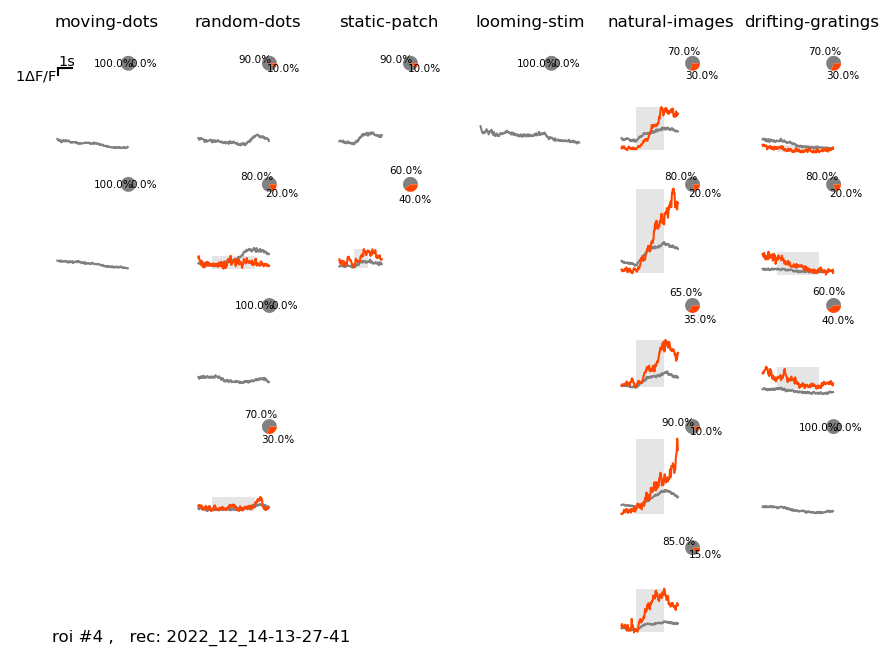

In [13]:
dataIndex, roiIndex = 0, 3
data = Data(SESSIONS['files'][dataIndex], verbose=False)
data.build_dFoF(verbose=False)
fig = plot_average_visually_evoked_activity2(data, roiIndex=roiIndex, pupil_threshold=2.9, running_speed_threshold=0.1, metric='locomotion')

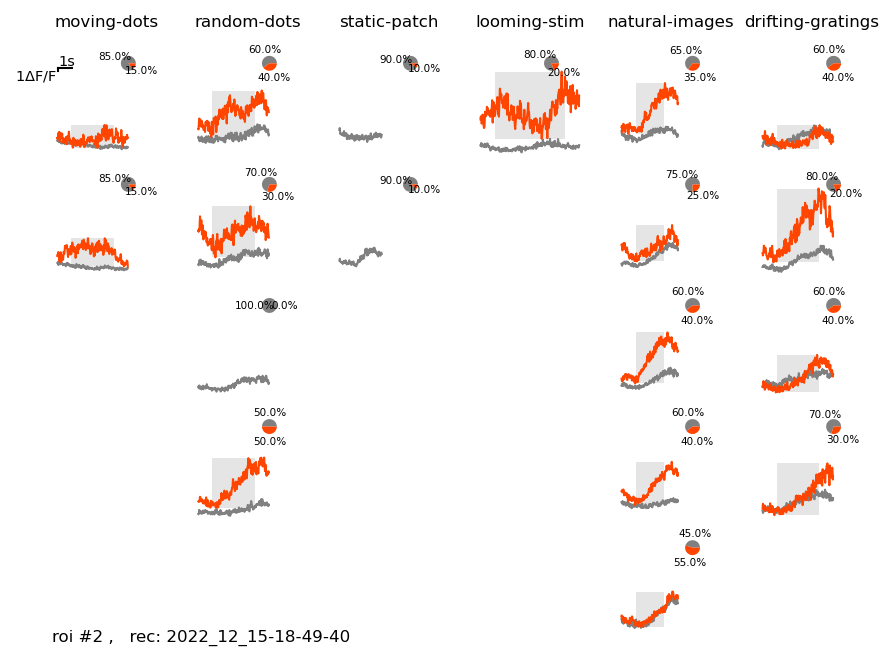

In [14]:
dataIndex, roiIndex = 2, 1
data = Data(SESSIONS['files'][dataIndex], verbose=False)
data.build_dFoF(verbose=False)
#fig = plot_average_visually_evoked_activity(data, roiIndex=roiIndex, pupil_threshold=2.9)
fig = plot_average_visually_evoked_activity2(data, roiIndex=roiIndex, pupil_threshold=2.9, running_speed_threshold=0.1, metric='locomotion')

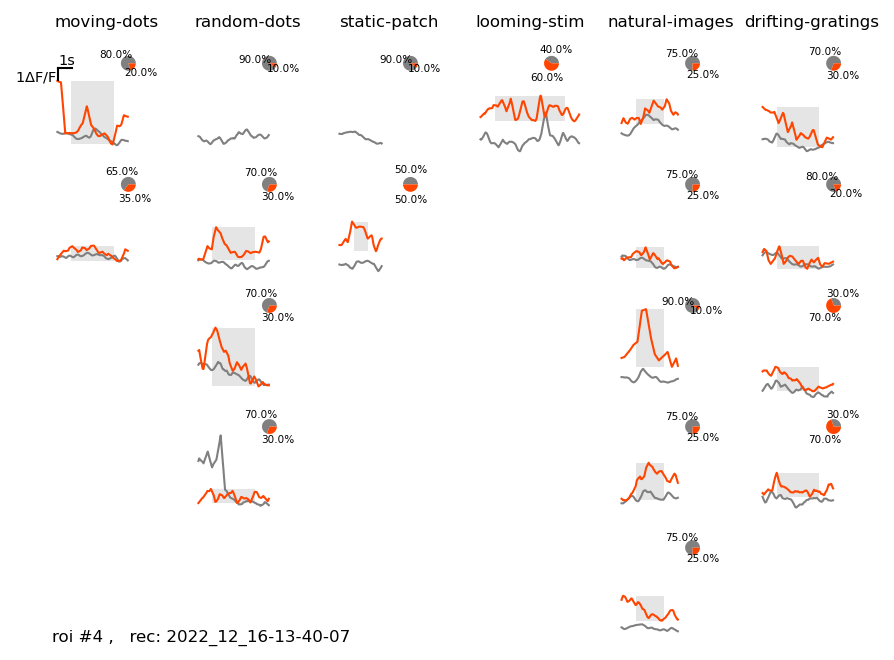

In [18]:
dataIndex, roiIndex = 7, 3
data = Data(SESSIONS['files'][dataIndex], verbose=False)
data.build_dFoF(verbose=False)
#fig = plot_average_visually_evoked_activity(data, roiIndex=roiIndex, pupil_threshold=2.9)
fig = plot_average_visually_evoked_activity2(data, roiIndex=roiIndex, pupil_threshold=2.9, running_speed_threshold=0.1, metric='locomotion')

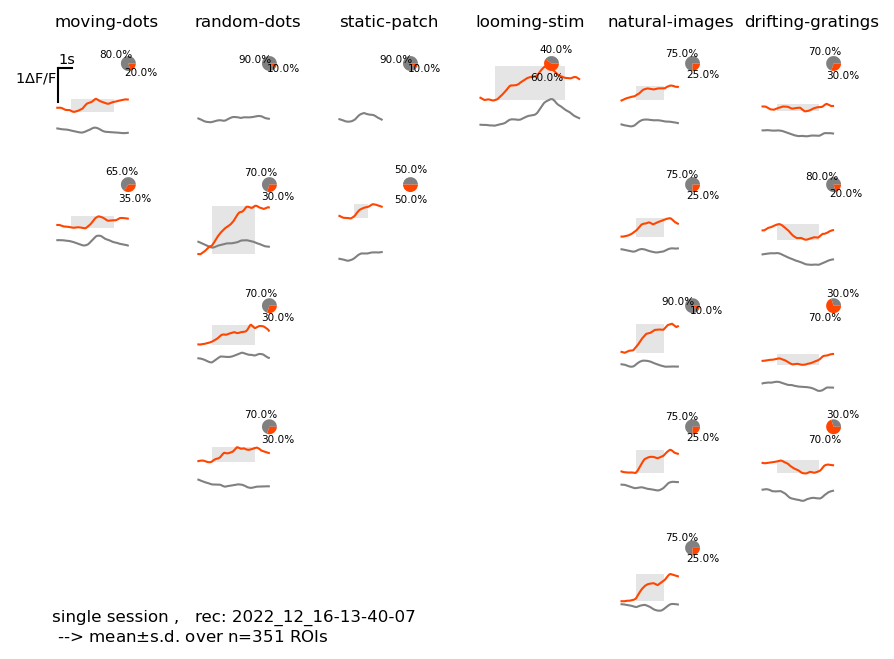

In [19]:
dataIndex, roiIndex = 7, None
data = Data(SESSIONS['files'][dataIndex], verbose=False)
data.build_dFoF(verbose=False)
#fig = plot_average_visually_evoked_activity(data, roiIndex=roiIndex, pupil_threshold=2.9)
fig = plot_average_visually_evoked_activity2(data, roiIndex=roiIndex, pupil_threshold=2.9, running_speed_threshold=0.1, metric='locomotion')

# SST Keta vs Saline Cibele and Sofia 2024-2025

In [20]:
datafolder = os.path.join(os.path.expanduser('~'), 'DATA', 'In_Vivo_experiments','my_experiments','All_NWBs')
SESSIONS = scan_folder_for_NWBfiles(datafolder)
SESSIONS['nwbfiles'] = [os.path.basename(f) for f in SESSIONS['files']]

inspecting the folder "C:\Users\laura.gonzalez\DATA\In_Vivo_experiments\my_experiments\All_NWBs" [...]
 -> found n=20 datafiles (in 31.3s) 


In [21]:
index = 8
filename = SESSIONS['files'][index]
data = Data(filename,
            verbose=False)
data.build_dFoF(verbose=False)

print(data.protocols)

['injection-monitoring']


Text(1, 1, ' low arousal')

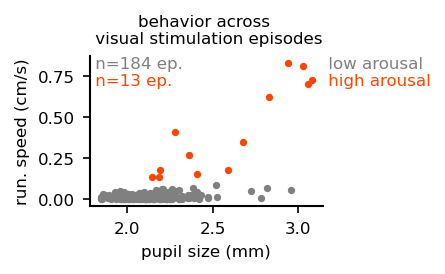

In [24]:
fig, ax = plot_behavior_in_episodes(data, running_speed_threshold=0.1, metric='locomotion')
ax.set_title('behavior across \n visual stimulation episodes')
ax.annotate('\n high arousal', (1, 1), color='orangered', xycoords='axes fraction', va='top')
ax.annotate(' low arousal', (1, 1), color='grey', xycoords='axes fraction', va='top')

'Data' object has no attribute 'pupil_diameter'
'Data' object has no attribute 'pupil_diameter'
'Data' object has no attribute 'pupil_diameter'


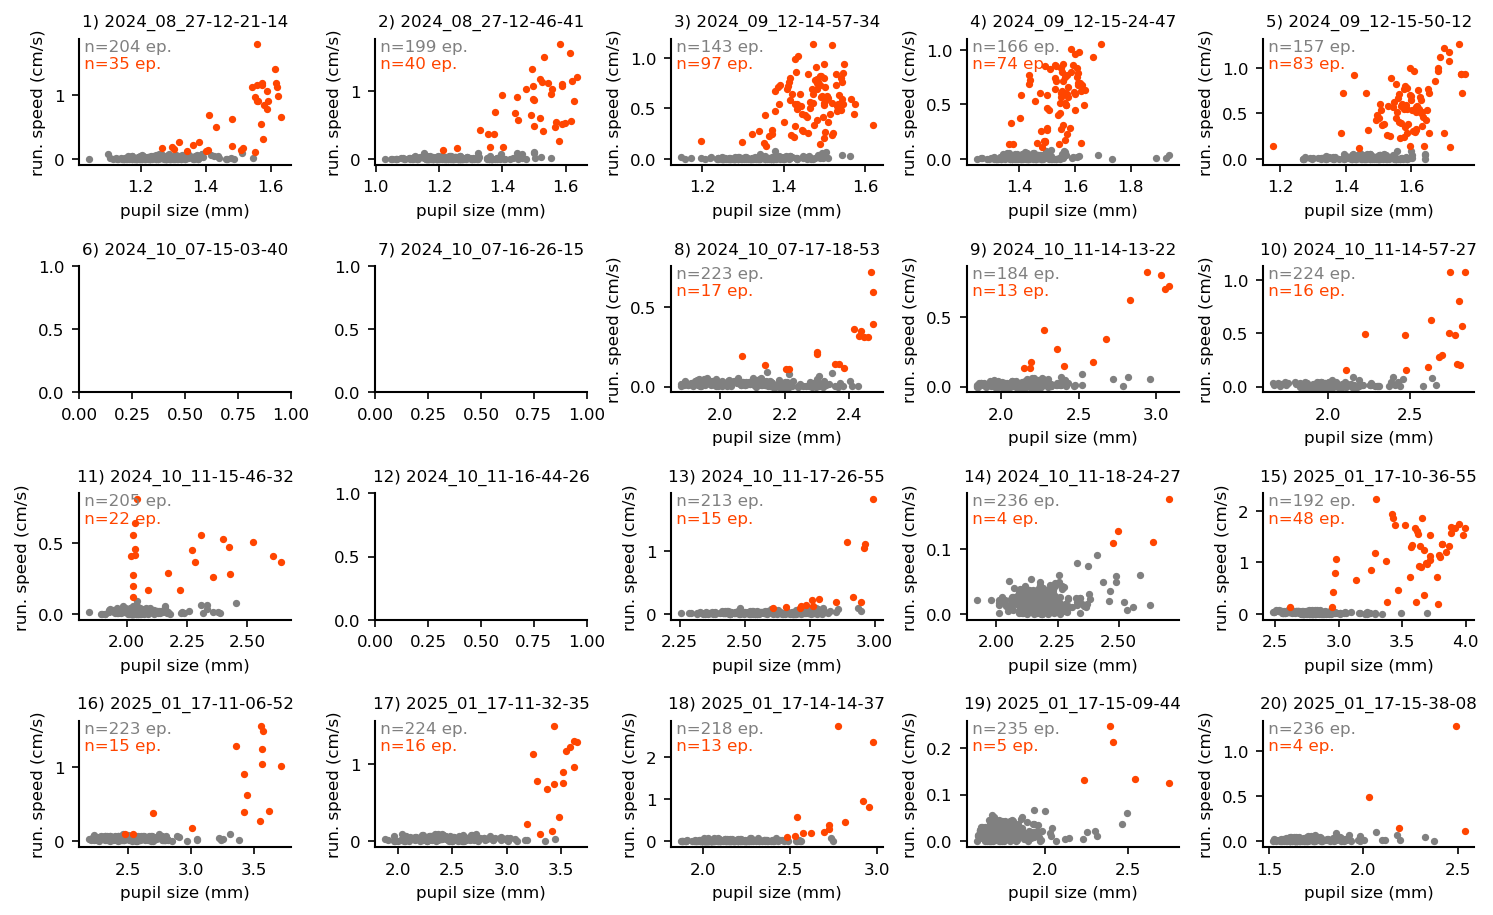

In [26]:
rows = 4
cols = 5
fig, AX = pt.plt.subplots(rows, cols, figsize=(12,7))
pt.plt.subplots_adjust(wspace=0.4, hspace=0.8)

for f, filename in enumerate(SESSIONS['files']):
    try:
        data = Data(filename, verbose=False)
        plot_behavior_in_episodes(data, ax=AX[int(f/5)][f%5], running_speed_threshold=0.1, metric='locomotion')
    except Exception as e:
        print(e)
    AX[int(f/5)][f%5].set_title(str(f+1)+') '+data.filename.replace('.nwb',''), fontsize=8)


for i in range(rows*cols-len(SESSIONS['files'])):
    AX[-1][i*(-1) - 1].axis('off')

(32, 42525)
0.7109597
hey


ValueError: x and y must have same first dimension, but have shapes (72199,) and (1,)

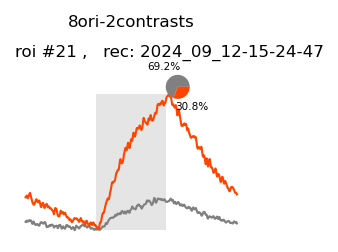

In [44]:
dataIndex, roiIndex = 3, 20
data = Data(SESSIONS['files'][dataIndex], verbose=False)
data.build_dFoF(verbose=False)
data.build_running_speed()

(32, 42525)
0.7109597


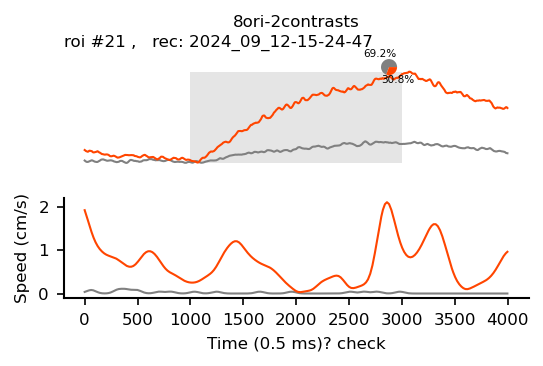

In [100]:
fig = plot_average_visually_evoked_activity3(data, roiIndex=roiIndex, running_speed_threshold=0.1)

(31, 42543)
0.89178467
hey


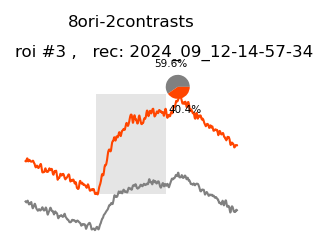

(31, 42543)
0.89178467
hey


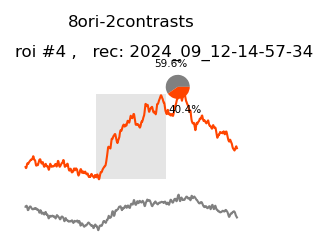

(31, 42543)
0.89178467
hey


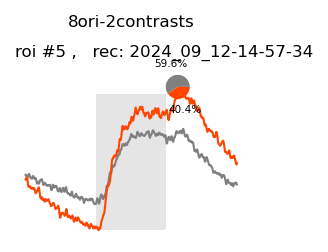

(31, 42543)
0.89178467
hey


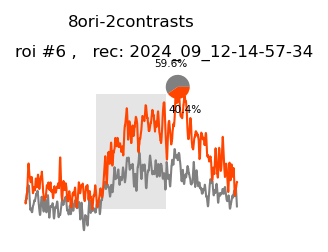

(32, 42525)
0.7109597
hey


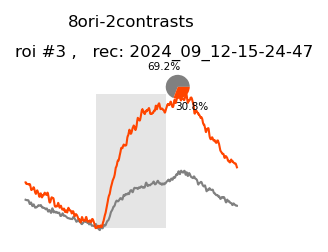

(32, 42525)
0.7109597
hey


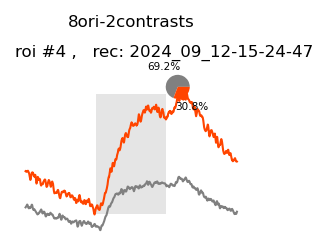

(32, 42525)
0.7109597
hey


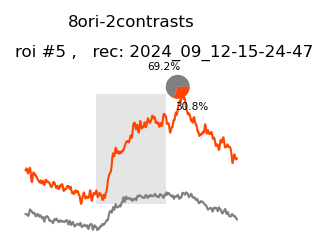

(32, 42525)
0.7109597
hey


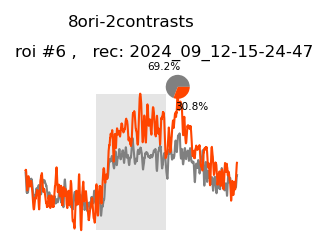

(29, 42534)
0.9853162
hey


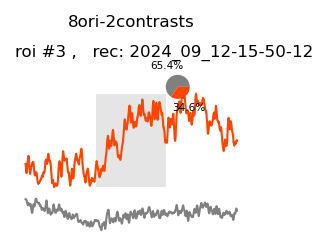

(29, 42534)
0.9853162
hey


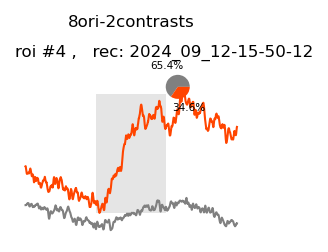

(29, 42534)
0.9853162
hey


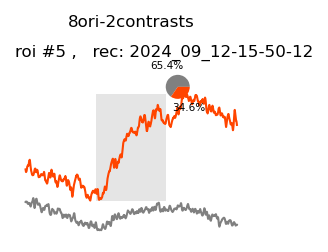

(29, 42534)
0.9853162
hey


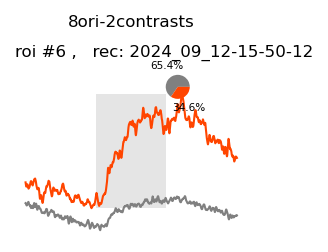

C:\Users\laura.gonzalez\AppData\Local\Temp\ipykernel_42852\3960974318.py:70: SyntaxWarning: invalid escape sequence '\p'
  AX[0][0].annotate('single session ,   rec: %s \n --> mean$\pm$s.d. over n=%i ROIs' % (\


AttributeError: 'Data' object has no attribute 'pupil_diameter'

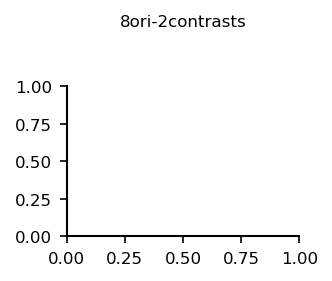

In [28]:
for i in range(2,10):
    for j in range(2,6):
        dataIndex, roiIndex = i, j
        data = Data(SESSIONS['files'][dataIndex], verbose=False)
        data.build_dFoF(verbose=False)
        fig = plot_average_visually_evoked_activity3(data, roiIndex=roiIndex, running_speed_threshold=0.1)
        plt.show()

# SST Keta vs Saline Taddy Yann 2023

not enough data!!!

In [ ]:
datafolder = os.path.join(os.path.expanduser('~'), 'DATA', 'In_Vivo_experiments', 'SST-Ketamine-vs-Saline', 'All_NWBs')
SESSIONS = scan_folder_for_NWBfiles(datafolder)
SESSIONS['nwbfiles'] = [os.path.basename(f) for f in SESSIONS['files']]

In [ ]:
index = 3
filename = SESSIONS['files'][index]
data = Data(filename,
            verbose=False)
data.build_dFoF(verbose=False)

In [ ]:
fig, ax = plot_behavior_in_episodes(data, running_speed_threshold=0.1)
ax.set_title('behavior across \n visual stimulation episodes')
ax.annotate('\n high arousal', (1, 1), color='orangered', xycoords='axes fraction', va='top')
ax.annotate(' low arousal', (1, 1), color='grey', xycoords='axes fraction', va='top')

In [ ]:
index = 0
filename = SESSIONS['files'][index]
data = Data(filename,
            verbose=False)
data.build_dFoF(verbose=False)

In [ ]:
fig, ax = plot_behavior_in_episodes(data, running_speed_threshold=0.1)
ax.set_title('behavior across \n visual stimulation episodes')
ax.annotate('\n high arousal', (1, 1), color='orangered', xycoords='axes fraction', va='top')
ax.annotate(' low arousal', (1, 1), color='grey', xycoords='axes fraction', va='top')